## IMPORTS

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import joblib
# Vizualisation settings
sc.set_figure_params(dpi=100, frameon=False, vector_friendly=True)

### Reading data

In [2]:
adata = sc.read_h5ad('../data/adata_qc.h5ad')
adata.layers['counts'] = adata.X.copy()
print(adata)
print("var index name:", adata.var.index.name)
print("var columns:", adata.var.columns.tolist()[:5])

AnnData object with n_obs × n_vars = 98976 × 19027
    obs: 'donor_id', 'sex_ontology_term_id', 'cell_type_ontology_term_id', 'luad_histologic_subtype', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'author_cell_type_level_1', 'author_cell_type_level_2', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'is_doublet'
    var: 'gene_symbol', 'feature_is_filtered', 'feature_name', 'feature_reference

## TRU subtype manual classification

In [3]:
extended_markers = {
    'TRU': ['TTF1','SFTPA1','SFTPA2','SFTPB','SFTPC','NAPSA','ABCA3','AGER','LPCAT1','SLC34A2'],
    'PP':  ['MKI67','PCNA','TOP2A','CDK1','CCNB1','E2F1','MCM2','AURKA','BUB1','FOXM1'],
    'PI':  ['IL6','CXCL1','CXCL2','CXCL8','CCL2','NFKB1','IL1B','TGFB1','CD274','STAT3']
}

for subtype, genes in extended_markers.items():
    found = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]
    print(f"{subtype}: found {len(found)}/10 — {found}")
    print(f"  Missing: {missing}")

TRU: found 8/10 — ['TTF1', 'SFTPA1', 'SFTPA2', 'SFTPB', 'SFTPC', 'NAPSA', 'ABCA3', 'SLC34A2']
  Missing: ['AGER', 'LPCAT1']
PP: found 10/10 — ['MKI67', 'PCNA', 'TOP2A', 'CDK1', 'CCNB1', 'E2F1', 'MCM2', 'AURKA', 'BUB1', 'FOXM1']
  Missing: []
PI: found 10/10 — ['IL6', 'CXCL1', 'CXCL2', 'CXCL8', 'CCL2', 'NFKB1', 'IL1B', 'TGFB1', 'CD274', 'STAT3']
  Missing: []


In [4]:
tumor = adata[adata.obs['cell_group'] == 'Tumor'].copy()

results = []
for donor in tumor.obs['donor_id'].unique():
    donor_cells = tumor[tumor.obs['donor_id'] == donor]
    row = {'donor_id': donor}
    for subtype, genes in extended_markers.items():
        genes_present = [g for g in genes if g in tumor.var_names]
        expr = np.array(
            donor_cells[:, genes_present].X.mean(axis=0)
        ).flatten()
        row[f'{subtype}_score'] = expr.mean()
    results.append(row)

scores_df = pd.DataFrame(results).set_index('donor_id')
score_cols = ['TRU_score', 'PP_score', 'PI_score']
scores_df['TCGA_subtype'] = scores_df[score_cols].idxmax(axis=1)\
    .str.replace('_score', '')

print("\nSubtype distribution:")
print(scores_df['TCGA_subtype'].value_counts())
print("\nScores:")
print(scores_df)

adata.obs['TCGA_subtype'] = adata.obs['donor_id'].map(
    scores_df['TCGA_subtype'].to_dict()
)


Subtype distribution:
TCGA_subtype
TRU    13
PI      5
Name: count, dtype: int64

Scores:
          TRU_score  PP_score  PI_score TCGA_subtype
donor_id                                            
KNUH01     1.157823  0.105356  0.544780          TRU
KNUH02     0.235768  0.245402  0.339833           PI
KNUH03     0.277416  0.178431  0.359351           PI
KNUH04     0.304723  0.242474  0.409845           PI
KNUH05     1.123901  0.090652  0.280524          TRU
KNUH06     0.219391  0.036299  0.275347           PI
KNUH07     0.686220  0.266034  0.435953          TRU
KNUH08     1.912042  0.118346  0.348581          TRU
KNUH09     1.021397  0.082823  0.411195          TRU
KNUH11     0.923521  0.112156  0.536096          TRU
KNUH12     1.407367  0.095871  0.319429          TRU
KNUH13     1.037515  0.101095  0.639481          TRU
KNUH14     0.586617  0.168252  0.351333          TRU
KNUH16     1.432179  0.060326  0.309595          TRU
KNUH18     1.673019  0.078248  0.475141          TRU
KNUH19  

### Tumor specificity

249/249 генов есть в sc


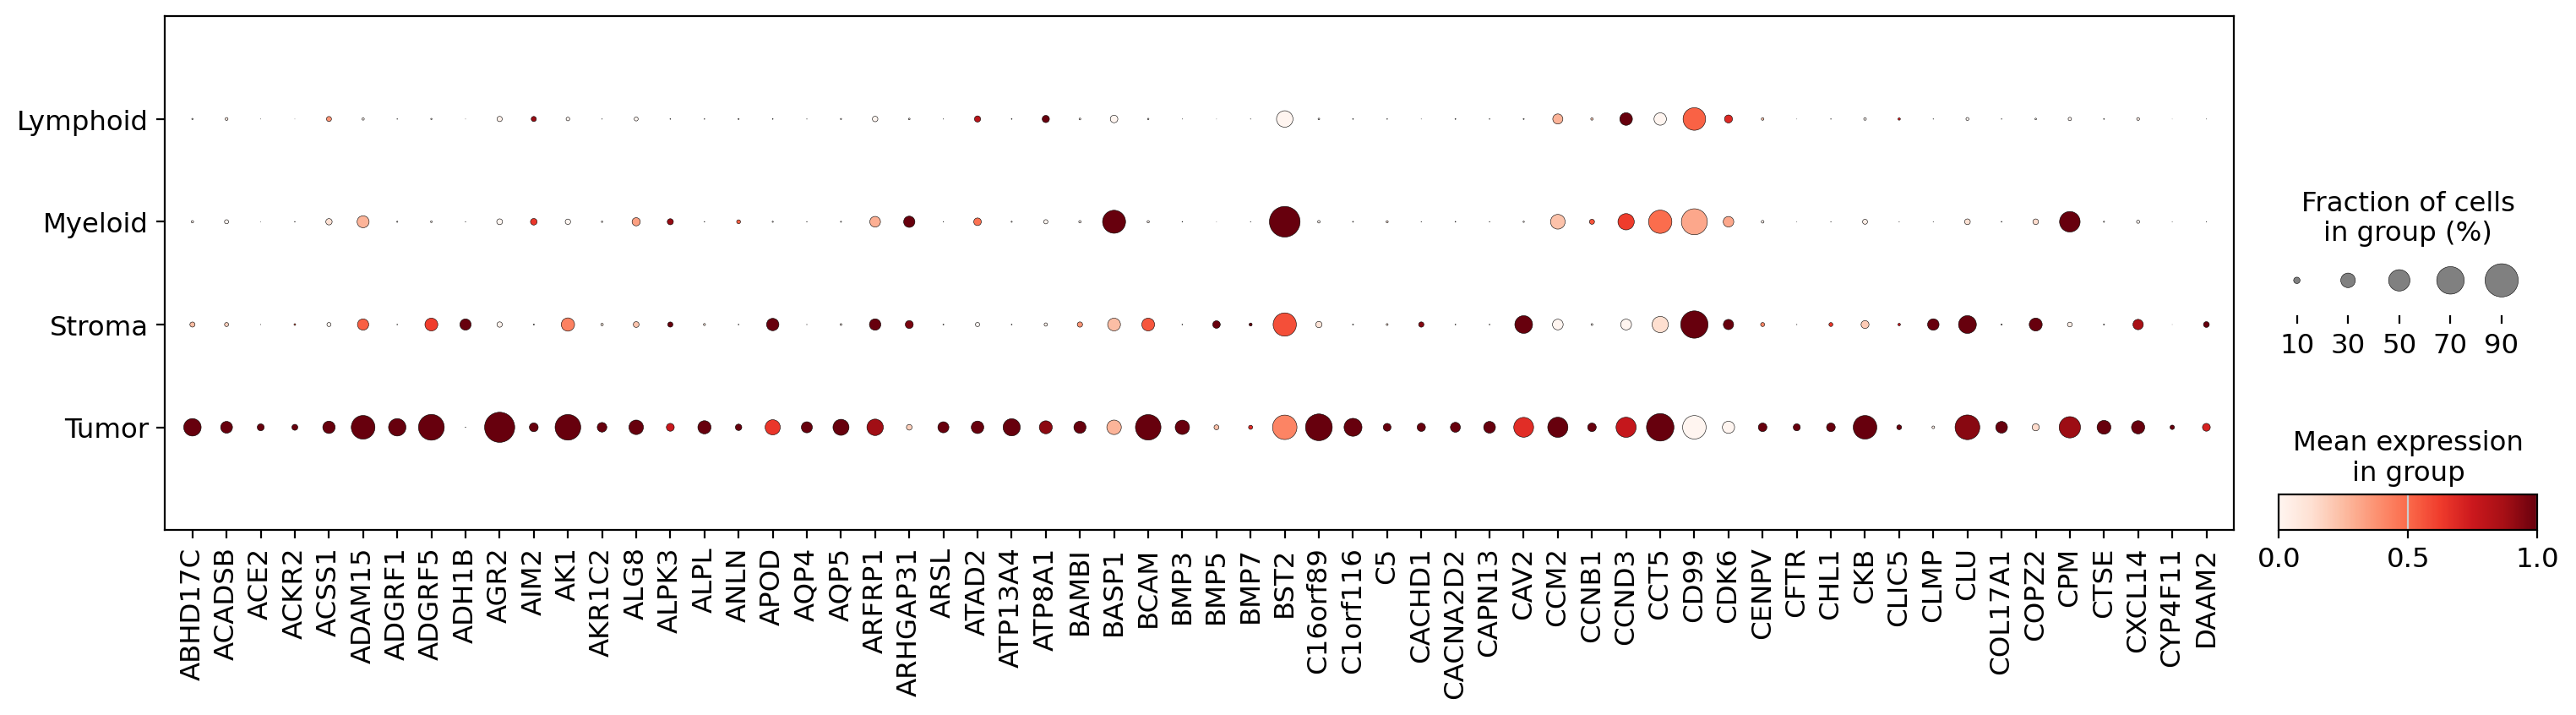


=== Топ tumor-specific ===
GJB3        0.960175
XDH         0.958887
RNF39       0.957152
SPDEF       0.955731
TOX3        0.954927
FOXA2       0.953863
AQP4        0.946259
ADGRF1      0.945668
BMP3        0.943904
PRSS22      0.936232
CYP4F11     0.936124
CFTR        0.935036
CAPN13      0.934529
WDR72       0.932167
PDZK1IP1    0.931531
ACE2        0.931220
ATP13A4     0.929869
C1orf116    0.923350
AQP5        0.921899
SULT2B1     0.920008
dtype: float32

=== Bottom tumor-specific ===
TSPAN7      0.187287
PLAC8       0.185631
KYNU        0.172414
TGFBI       0.169548
PGM2        0.165280
CD99        0.162129
SPOCK1      0.155475
TIMP2       0.141401
FZD10       0.139192
IQGAP2      0.135459
SLFN11      0.134869
COPZ2       0.128262
ARHGAP31    0.120572
TUBB6       0.120483
LDLRAD4     0.094151
CLMP        0.049586
GRAMD1B     0.045902
ITIH5       0.037843
MARCO       0.021539
ADH1B       0.007427
dtype: float32

Genes with tumor_specificity > 0.5: 126
Genes with tumor_specificity <

In [5]:
current_genes = ['ABHD17C', 'ACADSB', 'ACE2', 'ACKR2', 'ACSS1', 'ADAM15', 'ADGRF1', 'ADGRF5', 'ADH1B', 'AGR2', 'AIM2', 'AK1', 'AKR1C2', 'ALG8', 'ALPK3', 'ALPL', 'ANLN', 'APOD', 'AQP4', 'AQP5', 'ARFRP1', 'ARHGAP31', 'ARSL', 'ATAD2', 'ATP13A4', 'ATP8A1', 'BAMBI', 'BASP1', 'BCAM', 'BMP3', 'BMP5', 'BMP7', 'BST2', 'C16orf89', 'C1orf116', 'C5', 'CACHD1', 'CACNA2D2', 'CAPN13', 'CAV2', 'CCM2', 'CCNB1', 'CCND3', 'CCT5', 'CD99', 'CDK6', 'CENPV', 'CFTR', 'CHL1', 'CKB', 'CLIC5', 'CLMP', 'CLU', 'COL17A1', 'COPZ2', 'CPM', 'CTSE', 'CXCL14', 'CYP4F11', 'DAAM2', 'DDIT3', 'DIAPH2', 'DOK4', 'DPP4', 'DRAM1', 'EFEMP1', 'EFNA1', 'EGFR', 'EGLN3', 'ELOVL6', 'FAM3C', 'FOLR1', 'FOXA2', 'FREM2', 'FZD10', 'GABRP', 'GAPDH', 'GARS1', 'GATA6', 'GCNT1', 'GFUS', 'GGTLC1', 'GJB2', 'GJB3', 'GPT2', 'GPX2', 'GRAMD1B', 'GSTP1', 'H2AJ', 'HDGFL3', 'HOXB6', 'IFI16', 'IFI6', 'IP6K3', 'IQGAP2', 'IRS2', 'ITFG1', 'ITGB3', 'ITIH5', 'KIT', 'KITLG', 'KREMEN1', 'KRT19', 'KYNU', 'LAMB3', 'LBR', 'LDHB', 'LDLRAD4', 'LFNG', 'LGALS4', 'LGI2', 'LRRN4', 'MALL', 'MANSC1', 'MARCO', 'MBIP', 'MECOM', 'MEGF9', 'MELTF', 'MET', 'MEX3A', 'MTAP', 'MTMR11', 'MX1', 'MX2', 'NAPSA', 'NIBAN1', 'NPTX1', 'NUDT8', 'ORM1', 'P3H2', 'PAK3', 'PAPSS2', 'PDE4D', 'PDGFC', 'PDZK1IP1', 'PEBP4', 'PEG10', 'PFKP', 'PGM2', 'PHACTR3', 'PHGDH', 'PKIA', 'PLAAT3', 'PLAAT4', 'PLAC8', 'PLCB4', 'PLEK2', 'PLOD2', 'PROS1', 'PRRX2', 'PRSS22', 'PTGR1', 'PTK6', 'QPCT', 'RASGRF1', 'RASL11A', 'RDH10', 'RET', 'RETREG1', 'RHOQ', 'RNASE1', 'RNF128', 'RNF39', 'ROS1', 'S100A10', 'S100A14', 'S100A6', 'SC5D', 'SCIN', 'SCN9A', 'SCNN1B', 'SCUBE2', 'SEC11C', 'SEC61G', 'SESN3', 'SFTA3', 'SFTPB', 'SFTPC', 'SFTPD', 'SGMS1', 'SHE', 'SHISA3', 'SIPA1L2', 'SLC12A2', 'SLC22A3', 'SLC26A4', 'SLC34A2', 'SLC35E3', 'SLC38A1', 'SLC4A4', 'SLC5A3', 'SLFN11', 'SMIM1', 'SNHG19', 'SNTA1', 'SNX21', 'SORBS2', 'SOX9', 'SPAG4', 'SPDEF', 'SPOCK1', 'SPTB', 'SRD5A1', 'SRD5A3', 'SRPX2', 'STK26', 'STMN1', 'STUM', 'SULT2B1', 'SYT7', 'TESC', 'TF', 'TFF3', 'TFPI', 'TFPI2', 'TGFBI', 'TIMM50', 'TIMP2', 'TLR2', 'TMEM125', 'TMEM150C', 'TMEM163', 'TMEM243', 'TMEM98', 'TMPRSS2', 'TNNT1', 'TNS4', 'TOX3', 'TREM1', 'TRNP1', 'TRPM4', 'TSPAN31', 'TSPAN7', 'TSPYL5', 'TUBB6', 'TUSC3', 'UBE2C', 'UBE2E3', 'UBE2T', 'UCK2', 'UNC13B', 'UNC5CL', 'VSIG2', 'WDR72', 'WIF1', 'XDH', 'ZNF486', 'ZNF626']

genes_present = [g for g in current_genes if g in adata.var_names]
print(f'{len(genes_present)}/{len(current_genes)} генов есть в sc')

sc.pl.dotplot(
    adata,
    var_names=genes_present[:60],
    groupby='cell_group',
    standard_scale='var',
    figsize=(18, 4)
)

group_means = pd.DataFrame(index=genes_present)
for group in adata.obs['cell_group'].unique():
    mask = adata.obs['cell_group'] == group
    sub = adata[mask, genes_present].X
    if hasattr(sub, 'toarray'):
        sub = sub.toarray()
    group_means[group] = sub.mean(axis=0)

tumor_spec = group_means['Tumor'] / (group_means.sum(axis=1) + 1e-6)
tumor_spec = tumor_spec.sort_values(ascending=False)

print('\n=== Топ tumor-specific ===')
print(tumor_spec.head(20))

print('\n=== Bottom tumor-specific ===')
print(tumor_spec.tail(20))

print(f'\nGenes with tumor_specificity > 0.5: {(tumor_spec > 0.5).sum()}')
print(f'Genes with tumor_specificity < 0.3: {(tumor_spec < 0.3).sum()}')
print(f'Median: {tumor_spec.median():.3f}')

## XGB classifier inference

In [ ]:
# ──────────────────────────────────────────────────────────────────
model     = joblib.load('../models/xgb_luad_boosted.pkl')
le        = joblib.load('../models/label_encoder_BIN.pkl')
top_genes = np.load('../models/supplementary/genes_final_BIN.npy', allow_pickle=True)

print(f"Genes in models: {len(top_genes)}")
print(f"Classes: {le.classes_}")

# ──────────────────────────────────────────────────────────────────
tumor = adata[adata.obs['cell_group'] == 'Tumor'].copy()
print(f"Tumor cells: {tumor.n_obs}")

# ──────────────────────────────────────────────────────────────────
genes_found   = [g for g in top_genes if g in tumor.var_names]
genes_missing = [g for g in top_genes if g not in tumor.var_names]
print(f"Genes found: {len(genes_found)}/{len(top_genes)}")
if genes_missing:
    print(f"Missing: {genes_missing[:10]}{'...' if len(genes_missing) > 10 else ''}")

# ──────────────────────────────────────────────────────────────────

tumor_sub = tumor[:, genes_found]

donors = tumor.obs['donor_id'].unique()
donor_expr = pd.DataFrame(index=donors, columns=genes_found, dtype=np.float32)

for donor in donors:
    mask = tumor.obs['donor_id'] == donor
    X = tumor_sub[mask].layers['counts']   # raw counts
    if hasattr(X, 'toarray'):
        X = X.toarray()
    donor_expr.loc[donor] = X.sum(axis=0)

# ──────────────────────────────────────────────────────────────────
for g in genes_missing:
    donor_expr[g] = 0.0
donor_expr = donor_expr[top_genes]

# ──────────────────────────────────────────────────────────────────
donor_expr = donor_expr.div(donor_expr.sum(axis=1), axis=0) * 1e6
donor_expr = np.log2(donor_expr + 1)

# ──────────────────────────────────────────────────────────────────
X_infer = donor_expr.values.astype(np.float32)

y_pred  = model.predict(X_infer)
y_prob  = model.predict_proba(X_infer)

results = pd.DataFrame({
    'donor_id':        donors,
    'subtype_pred':    le.inverse_transform(y_pred),
    'confidence':      y_prob.max(axis=1).round(3),
}, index=donors)

# ──────────────────────────────────────────────────────────────────
for i, cls in enumerate(le.classes_):
    results[f'prob_{cls}'] = y_prob[:, i].round(3)

print(results)
results.to_csv('./data/luad_subtype_predictions.csv', index=False)

Genes in models: 133
Classes: ['NON-TRU' 'TRU']
Tumor cells: 22163
Genes found: 133/133
       donor_id subtype_pred  confidence  prob_NON-TRU  prob_TRU
KNUH01   KNUH01          TRU       0.749         0.251     0.749
KNUH02   KNUH02          TRU       0.789         0.211     0.789
KNUH03   KNUH03          TRU       0.815         0.185     0.815
KNUH04   KNUH04          TRU       0.673         0.327     0.673
KNUH05   KNUH05          TRU       0.811         0.189     0.811
KNUH06   KNUH06          TRU       0.611         0.389     0.611
KNUH07   KNUH07          TRU       0.854         0.146     0.854
KNUH08   KNUH08          TRU       0.794         0.206     0.794
KNUH09   KNUH09          TRU       0.728         0.272     0.728
KNUH11   KNUH11          TRU       0.728         0.272     0.728
KNUH12   KNUH12          TRU       0.760         0.240     0.760
KNUH13   KNUH13          TRU       0.815         0.185     0.815
KNUH14   KNUH14          TRU       0.775         0.225     0.775
KN

### Increasing threshold

In [9]:
tru_idx = list(le.classes_).index('TRU')

THRESHOLD = 0.7
y_pred_strict = np.where(y_prob[:, tru_idx] > THRESHOLD, 'TRU', 'NON-TRU')

results['subtype_strict'] = y_pred_strict

print(results[['donor_id', 'prob_TRU', 'subtype_pred', 'subtype_strict']])
print('\nРаспределение при threshold=0.7:')
print(results['subtype_strict'].value_counts())

       donor_id  prob_TRU subtype_pred subtype_strict
KNUH01   KNUH01     0.749          TRU            TRU
KNUH02   KNUH02     0.789          TRU            TRU
KNUH03   KNUH03     0.815          TRU            TRU
KNUH04   KNUH04     0.673          TRU        NON-TRU
KNUH05   KNUH05     0.811          TRU            TRU
KNUH06   KNUH06     0.611          TRU        NON-TRU
KNUH07   KNUH07     0.854          TRU            TRU
KNUH08   KNUH08     0.794          TRU            TRU
KNUH09   KNUH09     0.728          TRU            TRU
KNUH11   KNUH11     0.728          TRU            TRU
KNUH12   KNUH12     0.760          TRU            TRU
KNUH13   KNUH13     0.815          TRU            TRU
KNUH14   KNUH14     0.775          TRU            TRU
KNUH16   KNUH16     0.800          TRU            TRU
KNUH18   KNUH18     0.836          TRU            TRU
KNUH19   KNUH19     0.725          TRU            TRU
KNUH20   KNUH20     0.815          TRU            TRU
KNUH22   KNUH22     0.843   